In [4]:
import numpy as np
import pandas as pd

In [5]:
np.random.seed(42)

In [7]:
n=200
sensor_id=np.random.randint(1001,1011,n)
temperature=np.round(np.random.normal(30,3,n),1)
humidity=np.round(np.random.uniform(40,90,n),1)
gas=np.random.randint(150,500,n)
time=pd.date_range(start="2026-07-01 09:00:00",periods=n,freq="min")

In [12]:
df=pd.DataFrame({
    "Time":time,
    "sensor_ID":sensor_id,
    "Temperature(C)":temperature,
    "Humidity(%)":humidity,
    "Gas(ppm)":gas})

In [17]:
df.to_csv("sensor_data.csv",index=False)

In [18]:
print(df.head(10))

                 Time  sensor_ID  Temperature(C)  Humidity(%)  Gas(ppm)
0 2026-07-01 09:00:00       1010            27.5         80.5       287
1 2026-07-01 09:01:00       1008            30.5         70.7       199
2 2026-07-01 09:02:00       1004            27.8         83.0       408
3 2026-07-01 09:03:00       1007            34.7         59.6       256
4 2026-07-01 09:04:00       1010            26.8         87.8       262
5 2026-07-01 09:05:00       1002            30.2         46.7       499
6 2026-07-01 09:06:00       1007            31.0         45.1       403
7 2026-07-01 09:07:00       1005            31.2         72.9       267
8 2026-07-01 09:08:00       1005            28.3         87.1       347
9 2026-07-01 09:09:00       1006            27.3         80.4       486


In [20]:
df.describe()

,Time,sensor_ID,Temperature(C),Humidity(%),Gas(ppm)
count,200,200.000000,200.000000,200.00000,200.000000
mean,2026-07-01 10:39:30,1005.415000,29.649000,64.96550,316.830000
min,2026-07-01 09:00:00,1001.000000,19.800000,40.10000,151.000000
25%,2026-07-01 09:49:45,1003.000000,27.675000,51.25000,232.500000
50%,2026-07-01 10:39:30,1005.000000,29.700000,65.45000,311.000000
75%,2026-07-01 11:29:15,1008.000000,31.925000,77.42500,404.250000
max,2026-07-01 12:19:00,1010.000000,37.900000,89.60000,499.000000
std,NaN,2.864227,3.198869,14.78066,99.502184


In [23]:
df.loc[df["Temperature(C)"]>30]

,Time,sensor_ID,Temperature(C),Humidity(%),Gas(ppm)
1,2026-07-01 09:01:00,1008,30.5,70.7,199
3,2026-07-01 09:03:00,1007,34.7,59.6,256
5,2026-07-01 09:05:00,1002,30.2,46.7,499
6,2026-07-01 09:06:00,1007,31.0,45.1,403
7,2026-07-01 09:07:00,1005,31.2,72.9,267
...,...,...,...,...,...
186,2026-07-01 12:06:00,1007,31.4,78.3,408
188,2026-07-01 12:08:00,1009,32.8,55.0,263
191,2026-07-01 12:11:00,1004,31.5,64.8,278
195,2026-07-01 12:15:00,1002,36.7,77.4,256


In [140]:
df[df["Gas(ppm)"]>400]

,Time,sensor_ID,Temperature(C),Humidity(%),Gas(ppm)
2,2026-07-01 09:02:00,1004,27.8,83.0,408
5,2026-07-01 09:05:00,1002,30.2,46.7,499
6,2026-07-01 09:06:00,1007,31.0,45.1,403
9,2026-07-01 09:09:00,1006,27.3,80.4,486
13,2026-07-01 09:13:00,1007,32.4,52.7,451
15,2026-07-01 09:15:00,1004,23.2,81.3,498
16,2026-07-01 09:16:00,1002,30.7,64.8,469
20,2026-07-01 09:20:00,1009,26.8,84.5,410
23,2026-07-01 09:23:00,1003,29.2,45.3,409
26,2026-07-01 09:26:00,1001,27.4,42.4,444


In [141]:
df.groupby("sensor_ID")["Temperature(C)"].mean()

sensor_ID
1001    29.714286
1002    28.975000
1003    30.792857
1004    29.327778
1005    30.289286
1006    29.052632
1007    29.405263
1008    30.064706
1009    30.139130
1010    28.723529
Name: Temperature(C), dtype: float64

In [26]:
import matplotlib.pyplot as plt

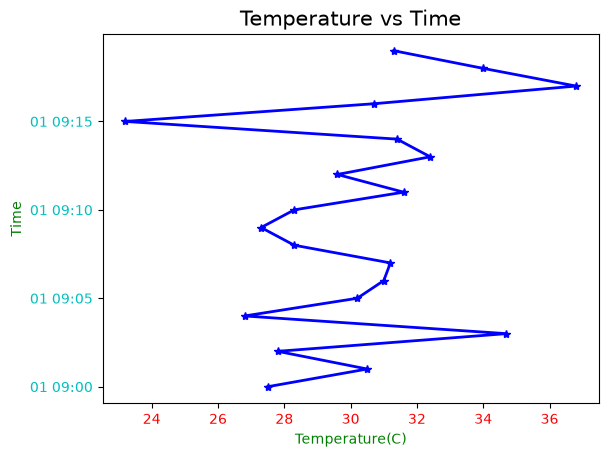

In [129]:
plt.plot((df["Temperature(C)"].head(20)),(df["Time"].head(20)),marker="*",linewidth=2,color="b")
plt.title("Temperature vs Time",color="k",fontsize="15")
plt.xlabel("Temperature(C)",color="g")
plt.ylabel("Time",color="g")
plt.xticks(color='r')
plt.yticks(color='c')
plt.show()

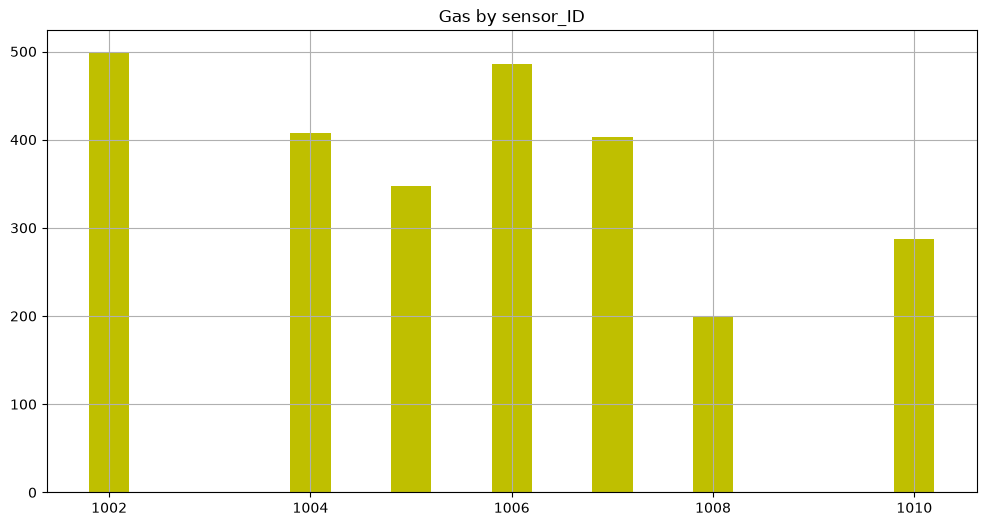

In [107]:
plt.figure(figsize=(12,6))
plt.bar((df["sensor_ID"].head(10)),(df["Gas(ppm)"].head(10)),width=0.4,color="y")
plt.title("Gas by sensor_ID")
plt.grid()
plt.show()

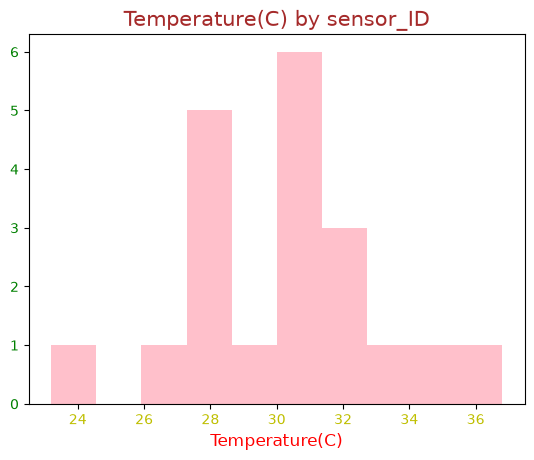

In [131]:
plt.hist(df["Temperature(C)"].head(20),color="pink")
plt.title("Temperature(C) by sensor_ID",color="brown",fontsize="15")
plt.xlabel("Temperature(C)",color="r",fontsize="12")
plt.xticks(color='y')
plt.yticks(color='g')
plt.show()

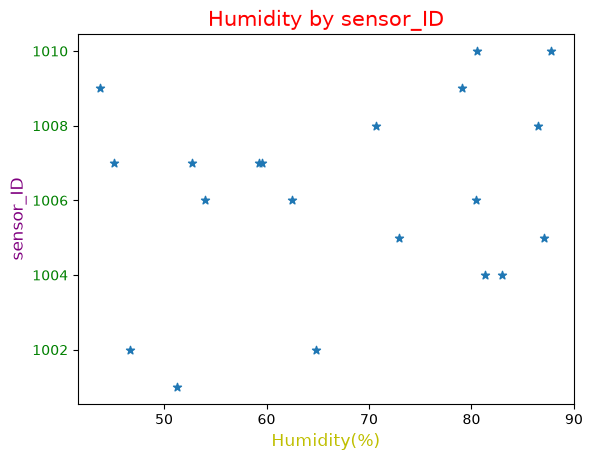

In [124]:
plt.scatter(df["Humidity(%)"].head(20),df["sensor_ID"].head(20),marker="*")
plt.title("Humidity by sensor_ID",color="red",fontsize="15")
plt.xlabel("Humidity(%)",color="y",fontsize="12")
plt.ylabel("sensor_ID",color="purple",fontsize="12")
plt.yticks(color="green")
plt.show()

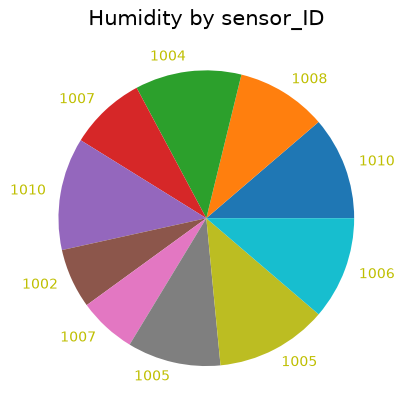

In [139]:
plt.pie(df["Humidity(%)"].head(10),labels=df["sensor_ID"].head(10),textprops={'color':'y'})
plt.title("Humidity by sensor_ID",color='k',fontsize='15')
plt.show()